In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display
from plotter import plot_series

import sys
sys.path.insert(0, str(Path("..").resolve()))
from run_registry import load_registry

RUNS_DIR = Path("../runs")
STRATEGIES = ["hold", "buybelow"]


def latest_entry(strategy: str) -> dict:
    matches = [entry for entry in load_registry(RUNS_DIR) if entry["strategy"] == strategy]
    if not matches:
        raise FileNotFoundError(f"No registry entries for {strategy!r}")
    return matches[-1]


def latest_steps(strategy: str) -> Path:
    entry = latest_entry(strategy)
    return RUNS_DIR / entry["folder"] / "steps.jsonl"


In [2]:
runs = {}
for name in STRATEGIES:
    entry = latest_entry(name)
    print(name, "->", entry)
    steps = pd.read_json(latest_steps(name), lines=True)
    runs[name] = steps
    display(steps)


hold -> {'id': '5l', 'folder': '26-07-17_18-15_5l', 'date_time': '26-07-17_18-15', 'strategy': 'hold', 'assets': ['BTC'], 'params': {}, 'start_date': '2021-01-01', 'end_date': '2026-07-16', 'interval': '1d'}


,step,time,prices,decision,balances,positions,equity
0,0,2021-01-01 00:00:00,"{'BTC': '29331.69', 'ETH': '728.91'}","[{'ticker': 'BTC', 'side': 'BUY', 'quantity': ...",{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",10000.000000
1,1,2021-01-02 00:00:00,"{'BTC': '32178.33', 'ETH': '774.56'}",[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",10970.499825
2,2,2021-01-03 00:00:00,"{'BTC': '33000.05', 'ETH': '978.28'}",[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",11250.647337
3,3,2021-01-04 00:00:00,"{'BTC': '31988.71', 'ETH': '1041.43'}",[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",10905.853021
4,4,2021-01-05 00:00:00,"{'BTC': '33949.53', 'ETH': '1099.56'}",[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",11574.351836
...,...,...,...,...,...,...,...
2018,2018,2026-07-12 00:00:00,"{'BTC': '63780.0', 'ETH': '1806.8'}",[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",21744.399999
2019,2019,2026-07-13 00:00:00,"{'BTC': '62334.52', 'ETH': '1776.72'}",[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",21251.595118
2020,2020,2026-07-14 00:00:00,"{'BTC': '65043.98', 'ETH': '1891.87'}",[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",22175.326413
2021,2021,2026-07-15 00:00:00,"{'BTC': '64756.28', 'ETH': '1917.86'}",[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",22077.241373


buybelow -> {'id': '7b', 'folder': '26-07-17_18-15_7b', 'date_time': '26-07-17_18-15', 'strategy': 'buybelow', 'assets': ['BTC'], 'params': {'target_price': '20000'}, 'start_date': '2021-01-01', 'end_date': '2026-07-16', 'interval': '1d'}


,step,time,prices,decision,balances,positions,equity
0,0,2021-01-01 00:00:00,"{'BTC': '29331.69', 'ETH': '728.91'}",[],{'USD': '10000'},[],10000.000000
1,1,2021-01-02 00:00:00,"{'BTC': '32178.33', 'ETH': '774.56'}",[],{'USD': '10000'},[],10000.000000
2,2,2021-01-03 00:00:00,"{'BTC': '33000.05', 'ETH': '978.28'}",[],{'USD': '10000'},[],10000.000000
3,3,2021-01-04 00:00:00,"{'BTC': '31988.71', 'ETH': '1041.43'}",[],{'USD': '10000'},[],10000.000000
4,4,2021-01-05 00:00:00,"{'BTC': '33949.53', 'ETH': '1099.56'}",[],{'USD': '10000'},[],10000.000000
...,...,...,...,...,...,...,...
2018,2018,2026-07-12 00:00:00,"{'BTC': '63780.0', 'ETH': '1806.8'}",[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.527126176611...",33620.107544
2019,2019,2026-07-13 00:00:00,"{'BTC': '62334.52', 'ETH': '1776.72'}",[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.527126176611...",32858.157199
2020,2020,2026-07-14 00:00:00,"{'BTC': '65043.98', 'ETH': '1891.87'}",[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.527126176611...",34286.384489
2021,2021,2026-07-15 00:00:00,"{'BTC': '64756.28', 'ETH': '1917.86'}",[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.527126176611...",34134.730288


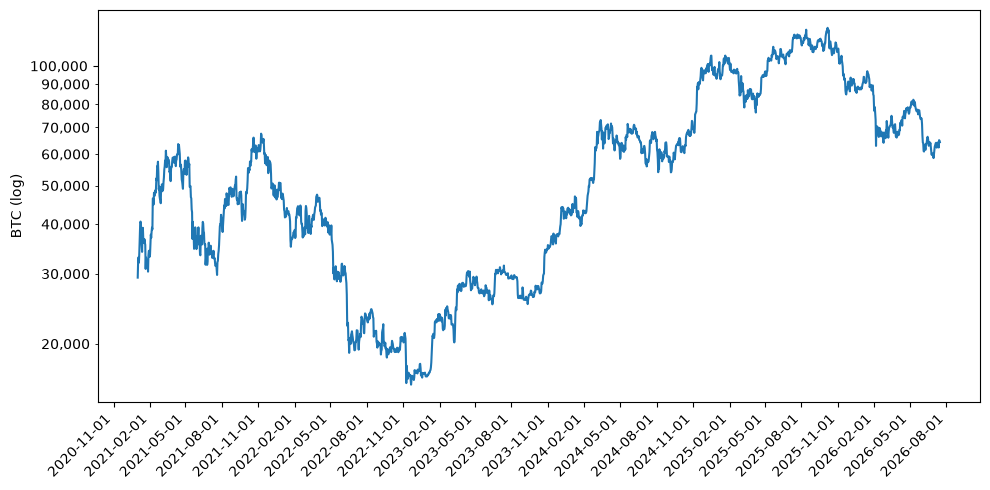

In [3]:
ASSET = "BTC"

steps = next(iter(runs.values())).copy()
steps[ASSET] = steps["prices"].map(lambda prices: float(prices[ASSET]))
plot_series(steps, ASSET)


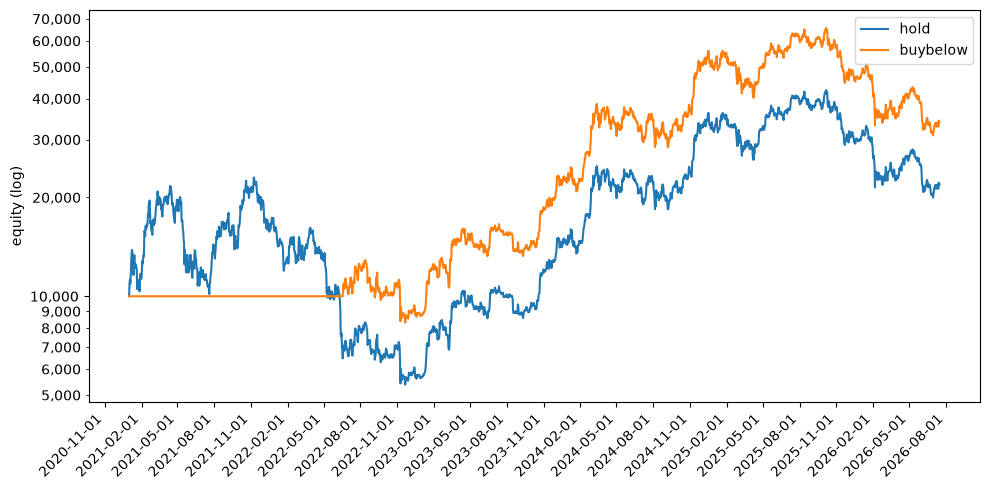

In [4]:
plot_series(runs, "equity")
